# RQ3 — Do Vt, Vc or max_evals correlate with overfitting or generalisation quality?

**Metric**: Spearman ρ between {Vt, Vc, max_evals} and {`change_perc_validate`, `overfitting`}.  
**Level**: fold (not aggregated — one row per algorithm × software × fold × budget).  
**Algorithms**: FirstImprovement (FI), GeneticProgrammingUniformConcat (GP), RandomSearch, UMDAAlgorithm (UMDA4GI) — all without LLM.  
**Data**: Perf<Cycles>, 5-fold CV, budgets {100, 250, 500, 750, 1000}.

**Variable definitions**:
- `Vt` = fraction of variants that compile **and** pass tests
- `Vc` = fraction of variants that compile (regardless of test outcome)
- `overfitting = change_perc_validate − change_perc_train` (positive = overfits)

**Bug fix note**: `local_search.py` (used by FI and RandomSearch) had a bug where `eval_compile`
was never incremented, causing Vc = 0.0 for all FI/RandomSearch runs. **This was fixed before
the current data was collected** (Fase 1 relaunched 2026-06-05 with the fix). Vc is therefore
valid for all four algorithms in this dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from pathlib import Path

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

RQ3_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ3_ALGOS)) &
    (df_all['llm_model'].isna())
].copy()

for col in ['change_perc_validate', 'change_perc_train', 'Vt', 'Vc', 'max_evals']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['max_evals'] = df['max_evals'].astype(int)
df = df[df['change_perc_validate'].notna() & (df['change_perc_validate'] != 0.0)]
df['overfit'] = df['change_perc_validate'] - df['change_perc_train']

legend_name_map = {
    'FirstImprovement':                'FI',
    'GeneticProgrammingUniformConcat': 'GP',
    'RandomSearch':                    'RandomS',
    'UMDAAlgorithm':                   'UMDA4GI',
}
software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j':        'Sat4J',
    'weka':         'Weka',
    'pngOptim':     'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']
TARGETS = ['change_perc_validate', 'overfit']
PREDICTORS = ['Vt', 'Vc', 'max_evals']

FIXED_COLORS = {
    'FirstImprovement':                cm.tab10(0),
    'GeneticProgrammingUniformConcat': cm.tab10(1),
    'RandomSearch':                    cm.tab10(2),
    'UMDAAlgorithm':                   cm.tab10(3),
}
color_map = {alg: FIXED_COLORS[alg] for alg in RQ3_ALGOS}

print(f'Total rows: {len(df)}')
print(df.groupby(['software', 'algorithm']).size().to_string())

Total rows: 394
software      algorithm                      
minisat_hack  FirstImprovement                   25
              GeneticProgrammingUniformConcat    25
              RandomSearch                       25
              UMDAAlgorithm                      25
pngOptim      FirstImprovement                   21
              GeneticProgrammingUniformConcat    23
              RandomSearch                       25
              UMDAAlgorithm                      25
sat4j         FirstImprovement                   25
              GeneticProgrammingUniformConcat    25
              RandomSearch                       25
              UMDAAlgorithm                      25
weka          FirstImprovement                   25
              GeneticProgrammingUniformConcat    25
              RandomSearch                       25
              UMDAAlgorithm                      25


## 0. Data Quality — Runs excluded from correlation analysis

Of the 400 no-LLM runs (4 algorithms × 4 softwares × 5 folds × 5 budgets), **4 are excluded** from RQ3 because `change_perc_validate` is NaN or exactly 0.0 — i.e., no improvement over the original was measured on the validation set. This leaves **396 rows** for the correlation analysis.

Note: in RQ1/RQ2, 11 runs had `patch_length = 0` (no better variant found). Only 4 of those 11 have `change_perc_validate = NaN or 0.0`; the remaining 7 have small non-zero validate values and are included here.

In [2]:
# Rows excluded from the correlation analysis (change_perc_validate NaN or exactly 0.0)
_base = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ3_ALGOS)) &
    (df_all['llm_model'].isna())
].copy()
_base['change_perc_validate'] = pd.to_numeric(_base['change_perc_validate'], errors='coerce')
_base['patch_length']         = pd.to_numeric(_base['patch_length'],         errors='coerce')

excluded = _base[
    _base['change_perc_validate'].isna() | (_base['change_perc_validate'] == 0.0)
][['software', 'algorithm', 'fold', 'max_evals', 'change_perc_validate', 'patch_length']
].sort_values(['software', 'algorithm', 'max_evals', 'fold']).reset_index(drop=True)

print(f'Rows excluded from RQ3 (change_perc_validate NaN or 0.0): {len(excluded)} / {len(_base)}')
display(excluded)

Rows excluded from RQ3 (change_perc_validate NaN or 0.0): 6 / 400


,software,algorithm,fold,max_evals,change_perc_validate,patch_length
0,pngOptim,FirstImprovement,1,750,0.0,6
1,pngOptim,FirstImprovement,3,750,0.0,7
2,pngOptim,FirstImprovement,1,1000,0.0,7
3,pngOptim,FirstImprovement,3,1000,0.0,7
4,pngOptim,GeneticProgrammingUniformConcat,1,1000,0.0,1
5,pngOptim,GeneticProgrammingUniformConcat,3,1000,0.0,4


## 1. Diagnostic — validity and variability of Vt and Vc per software

Vt and Vc are only **informative** where they vary. In softwares where all variants compile and pass
tests (Vt = 1.0), both Vt and Vc are constant and carry no information as predictors.

In [3]:
rows = []
for sw in sorted(df['software'].unique()):
    for alg in RQ3_ALGOS:
        sub = df[(df['software'] == sw) & (df['algorithm'] == alg)]
        if sub.empty: continue
        rows.append({
            'software': software_display_map.get(sw, sw),
            'algorithm': legend_name_map.get(alg, alg),
            'n': len(sub),
            'Vt_range': f'[{sub["Vt"].min():.3f}, {sub["Vt"].max():.3f}]',
            'Vc_range': f'[{sub["Vc"].min():.3f}, {sub["Vc"].max():.3f}]',
            'Vt_variable': sub['Vt'].std() > 0.01,
            'Vc_variable': sub['Vc'].std() > 0.01,
        })

diag = pd.DataFrame(rows).set_index(['software', 'algorithm'])
display(diag)

print('\nSummary of usable predictors:')
print('  max_evals : valid and variable for ALL algorithms and softwares')
print('  Vt        : valid and variable for ALL algorithms and softwares (compile-pipeline bug fixed for all 4)')
print('  Vc        : valid and variable for ALL algorithms and softwares (compile-pipeline bug fixed for all 4)')

n        Vt_range        Vc_range  Vt_variable  \
software     algorithm                                                    
MiniSAT-hack FI         25  [0.360, 0.564]  [0.480, 0.650]         True   
             GP         25  [0.460, 0.829]  [0.550, 0.870]         True   
             RandomS    25  [0.270, 0.430]  [0.380, 0.530]         True   
             UMDA4GI    25  [0.370, 0.653]  [0.430, 0.741]         True   
OptimPNG     FI         21  [0.356, 0.494]  [0.432, 0.560]         True   
             GP         23  [0.510, 0.852]  [0.580, 0.874]         True   
             RandomS    25  [0.330, 0.460]  [0.420, 0.540]         True   
             UMDA4GI    25  [0.450, 0.681]  [0.510, 0.734]         True   
Sat4J        FI         25  [0.280, 0.397]  [0.330, 0.436]         True   
             GP         25  [0.360, 0.815]  [0.400, 0.829]         True   
             RandomS    25  [0.180, 0.311]  [0.240, 0.377]         True   
             UMDA4GI    25  [0.300, 0.629]  [0.350, 0.662]         True   
Weka         FI         25  [0.224, 0.508]  [0.304, 0.512]         True   
             GP         25  [0.460, 0.837]  [0.460, 0.840]         True   
             RandomS    25  [0.258, 0.335]  [0.280, 0.370]         True   
             UMDA4GI    25  [0.370, 0.645]  [0.390, 0.651]         True   

                        Vc_variable  
software     algorithm               
MiniSAT-hack FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
OptimPNG     FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
Sat4J        FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
Weka         FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True


Summary of usable predictors:
  max_evals : valid and variable for ALL algorithms and softwares
  Vt        : valid and variable for ALL algorithms and softwares (compile-pipeline bug fixed for all 4)
  Vc        : valid and variable for ALL algorithms and softwares (compile-pipeline bug fixed for all 4)


## 2. Global Spearman — all algorithms, all softwares

Vt and Vc are now valid and variable in all 4 softwares (the compile-pipeline bug that kept them
constant at 1.0 in Sat4J/Weka/OptimPNG was fixed before this data was collected). The global pooled
correlation below mixes algorithms and softwares with different Vt/Vc ranges, which can dilute or
mask within-software effects — see Section 3 for the per-software breakdown, which is more informative.


In [4]:
rows = []
for pred in PREDICTORS:
    for tgt in TARGETS:
        rho, p = stats.spearmanr(df[pred], df[tgt])
        note = 'valid cross-algorithm, cross-software'
        rows.append({'predictor': pred, 'target': tgt,
                     'rho': round(rho, 3), 'p_value': round(p, 4), 'note': note})

corr_global = pd.DataFrame(rows)
corr_global['significant'] = corr_global['p_value'] < 0.05
corr_global['sig_label'] = corr_global['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)
print(f'Global Spearman correlations (n={len(df)}):')
display(corr_global.drop(columns='significant'))

Global Spearman correlations (n=394):


,predictor,target,rho,p_value,note,sig_label
0,Vt,change_perc_validate,-0.049,0.3311,"valid cross-algorithm, cross-software",ns
1,Vt,overfit,0.073,0.1462,"valid cross-algorithm, cross-software",ns
2,Vc,change_perc_validate,-0.107,0.0345,"valid cross-algorithm, cross-software",*
3,Vc,overfit,0.107,0.0331,"valid cross-algorithm, cross-software",*
4,max_evals,change_perc_validate,-0.222,0.0000,"valid cross-algorithm, cross-software",***
5,max_evals,overfit,0.044,0.3850,"valid cross-algorithm, cross-software",ns


## 3. Within-software Spearman — all algorithms, per software

Now that Vt and Vc are variable in all 4 softwares, per-software analysis (pooling all algorithms,
then breaking down per algorithm) is meaningful everywhere, not just in MiniSAT-hack.


In [5]:
df_mini = df[df['software'] == 'minisat_hack'].copy()  # kept for the scatter plot below
rows_all = []
for sw in desired_order:
    sw_data = df[df['software'] == sw]
    sw_name = software_display_map.get(sw, sw)
    print(f"{sw_name} rows: {len(sw_data)}")
    for alg in RQ3_ALGOS:
        sub = sw_data[sw_data['algorithm'] == alg]
        if sub.empty:
            continue
        print(f'  {legend_name_map[alg]:8s}  Vt=[{sub["Vt"].min():.3f},{sub["Vt"].max():.3f}]  Vc=[{sub["Vc"].min():.3f},{sub["Vc"].max():.3f}]  n={len(sub)}')

    for pred in PREDICTORS:
        for tgt in TARGETS:
            rho, p = stats.spearmanr(sw_data[pred], sw_data[tgt])
            rows_all.append({'software': sw_name, 'scope': 'all algos', 'predictor': pred,
                             'target': tgt, 'rho': round(rho, 3), 'p_value': round(p, 4),
                             'n': len(sw_data)})
            for alg in RQ3_ALGOS:
                sub = sw_data[sw_data['algorithm'] == alg]
                if len(sub) < 5:
                    continue
                rho_a, p_a = stats.spearmanr(sub[pred], sub[tgt])
                rows_all.append({'software': sw_name, 'scope': legend_name_map[alg], 'predictor': pred,
                                 'target': tgt, 'rho': round(rho_a, 3), 'p_value': round(p_a, 4), 'n': len(sub)})
    print()

all_df = pd.DataFrame(rows_all)
all_df['sig'] = all_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

for sw_name in [software_display_map.get(sw, sw) for sw in desired_order]:
    sub = all_df[all_df['software'] == sw_name]
    display(f'Spearman ρ within {sw_name}:')
    display(sub.pivot_table(index=['scope', 'predictor'], columns='target',
                             values=['rho', 'p_value'], aggfunc='first').round(3))


MiniSAT-hack rows: 100
  FI        Vt=[0.360,0.564]  Vc=[0.480,0.650]  n=25
  GP        Vt=[0.460,0.829]  Vc=[0.550,0.870]  n=25
  RandomS   Vt=[0.270,0.430]  Vc=[0.380,0.530]  n=25
  UMDA4GI   Vt=[0.370,0.653]  Vc=[0.430,0.741]  n=25

Sat4J rows: 100
  FI        Vt=[0.280,0.397]  Vc=[0.330,0.436]  n=25
  GP        Vt=[0.360,0.815]  Vc=[0.400,0.829]  n=25
  RandomS   Vt=[0.180,0.311]  Vc=[0.240,0.377]  n=25
  UMDA4GI   Vt=[0.300,0.629]  Vc=[0.350,0.662]  n=25

Weka rows: 100
  FI        Vt=[0.224,0.508]  Vc=[0.304,0.512]  n=25
  GP        Vt=[0.460,0.837]  Vc=[0.460,0.840]  n=25
  RandomS   Vt=[0.258,0.335]  Vc=[0.280,0.370]  n=25
  UMDA4GI   Vt=[0.370,0.645]  Vc=[0.390,0.651]  n=25

OptimPNG rows: 94
  FI        Vt=[0.356,0.494]  Vc=[0.432,0.560]  n=21
  GP        Vt=[0.510,0.852]  Vc=[0.580,0.874]  n=23
  RandomS   Vt=[0.330,0.460]  Vc=[0.420,0.540]  n=25
  UMDA4GI   Vt=[0.450,0.681]  Vc=[0.510,0.734]  n=25



'Spearman ρ within MiniSAT-hack:'

p_value                          rho        
target              change_perc_validate overfit change_perc_validate overfit
scope     predictor                                                          
FI        Vc                       0.170   0.590               -0.284  -0.113
          Vt                       0.227   0.465               -0.251  -0.153
          max_evals                0.080   0.628               -0.357  -0.102
GP        Vc                       0.043   0.785               -0.408  -0.057
          Vt                       0.041   0.730               -0.411  -0.073
          max_evals                0.067   0.780               -0.373  -0.059
RandomS   Vc                       0.003   0.002               -0.573  -0.577
          Vt                       0.098   0.036               -0.339  -0.422
          max_evals                0.103   0.838               -0.333   0.043
UMDA4GI   Vc                       0.107   0.233               -0.330   0.248
          Vt                       0.052   0.420               -0.393   0.169
          max_evals                0.067   0.171               -0.373   0.282
all algos Vc                       0.986   0.771                0.002   0.029
          Vt                       0.797   0.828                0.026   0.022
          max_evals                0.000   0.728               -0.362   0.035

'Spearman ρ within Sat4J:'

p_value                          rho        
target              change_perc_validate overfit change_perc_validate overfit
scope     predictor                                                          
FI        Vc                       0.005   0.367               -0.540   0.188
          Vt                       0.003   0.306               -0.574   0.213
          max_evals                0.031   0.154               -0.431   0.294
GP        Vc                       0.962   0.383                0.010   0.182
          Vt                       0.969   0.422               -0.008   0.168
          max_evals                0.882   0.226               -0.031   0.251
RandomS   Vc                       0.086   0.323               -0.350  -0.206
          Vt                       0.132   0.620               -0.310  -0.104
          max_evals                0.099   0.766               -0.337   0.063
UMDA4GI   Vc                       0.222   0.964               -0.253  -0.010
          Vt                       0.260   0.871               -0.234   0.034
          max_evals                0.148   0.926               -0.298   0.020
all algos Vc                       0.304   0.071                0.104   0.181
          Vt                       0.233   0.058                0.120   0.191
          max_evals                0.006   0.138               -0.273   0.149

'Spearman ρ within Weka:'

p_value                          rho        
target              change_perc_validate overfit change_perc_validate overfit
scope     predictor                                                          
FI        Vc                       0.790   0.667                0.056   0.090
          Vt                       0.588   0.419               -0.114  -0.169
          max_evals                0.219   0.058                0.255   0.384
GP        Vc                       0.182   0.632               -0.276  -0.101
          Vt                       0.104   0.342               -0.333  -0.198
          max_evals                0.076   0.538               -0.361  -0.129
RandomS   Vc                       0.259   0.402               -0.235  -0.175
          Vt                       0.511   0.640               -0.138  -0.098
          max_evals                0.588   0.050                0.114   0.396
UMDA4GI   Vc                       0.511   0.748               -0.138  -0.068
          Vt                       0.795   0.895               -0.055   0.028
          max_evals                0.889   0.723               -0.029   0.075
all algos Vc                       0.999   0.464               -0.000   0.074
          Vt                       0.926   0.756               -0.009   0.032
          max_evals                0.956   0.076               -0.006   0.178

'Spearman ρ within OptimPNG:'

p_value                          rho        
target              change_perc_validate overfit change_perc_validate overfit
scope     predictor                                                          
FI        Vc                       0.505   0.701                0.154   0.089
          Vt                       0.363   0.573                0.209   0.131
          max_evals                0.006   0.127               -0.582  -0.344
GP        Vc                       0.330   0.420               -0.213  -0.177
          Vt                       0.229   0.298               -0.261  -0.227
          max_evals                0.041   0.116               -0.430  -0.337
RandomS   Vc                       0.921   0.551               -0.021   0.125
          Vt                       0.102   0.590               -0.334  -0.113
          max_evals                0.087   0.823               -0.349  -0.047
UMDA4GI   Vc                       0.475   0.010               -0.150   0.507
          Vt                       0.660   0.002               -0.092   0.592
          max_evals                0.198   0.004               -0.267   0.557
all algos Vc                       0.072   0.395                0.187   0.089
          Vt                       0.111   0.490                0.165   0.072
          max_evals                0.000   0.965               -0.380  -0.005

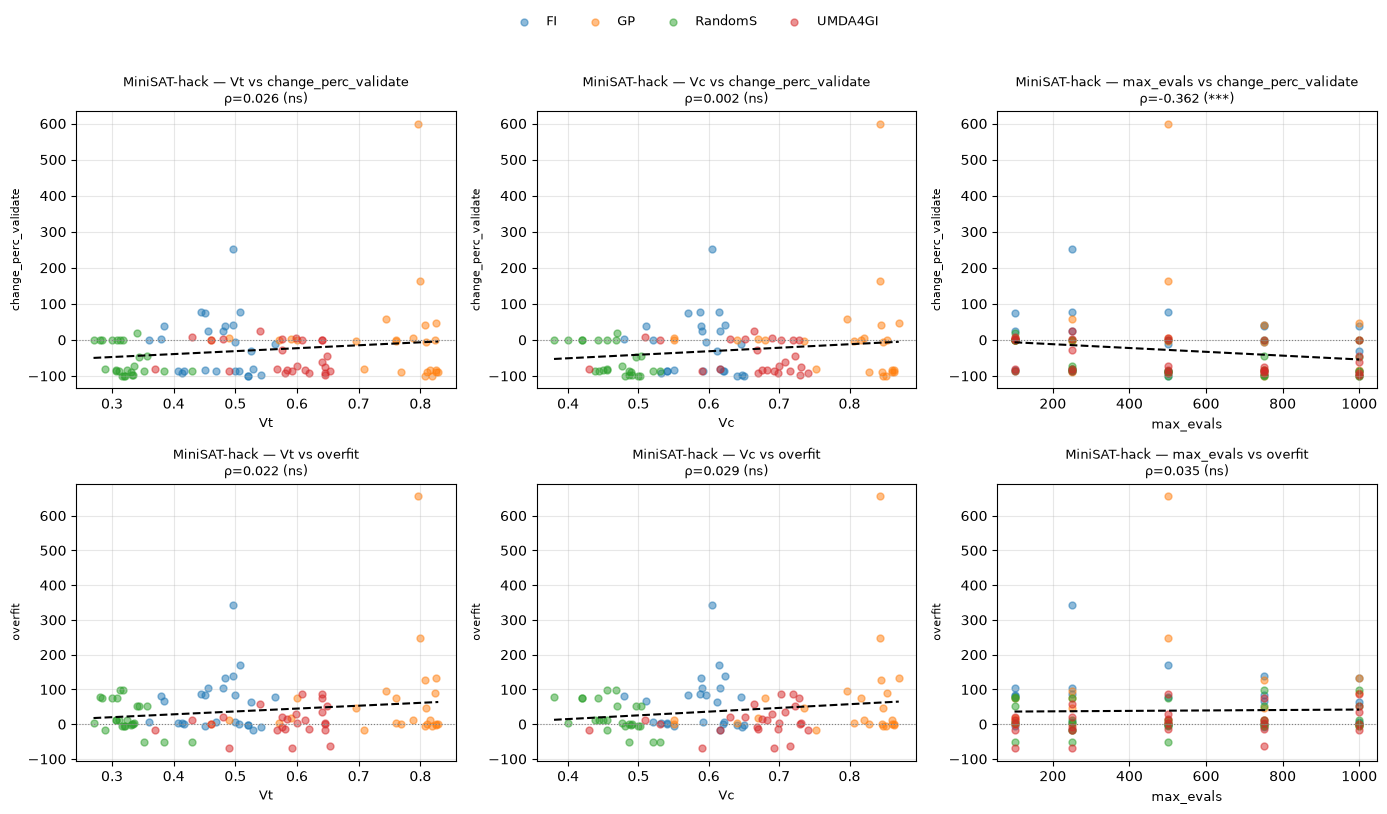

In [6]:
fig, axes = plt.subplots(len(TARGETS), len(PREDICTORS), figsize=(14, 8))

for row_i, tgt in enumerate(TARGETS):
    for col_i, pred in enumerate(PREDICTORS):
        ax = axes[row_i, col_i]
        for alg in RQ3_ALGOS:
            sub = df_mini[df_mini['algorithm'] == alg]
            ax.scatter(sub[pred], sub[tgt],
                       label=legend_name_map[alg], color=color_map[alg], alpha=0.5, s=25)
        x, y = df_mini[pred].values, df_mini[tgt].values
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(np.polyfit(x, y, 1), xs), 'k--', linewidth=1.5)
        rho, p = stats.spearmanr(x, y)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'MiniSAT-hack — {pred} vs {tgt}\nρ={rho:.3f} ({sig})', fontsize=9)
        ax.set_xlabel(pred, fontsize=9)
        ax.set_ylabel(tgt, fontsize=8)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(RQ3_ALGOS), fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('plots/RQ3_minisat_scatter.svg', format='svg', bbox_inches='tight')
plt.show()

## 4. max_evals vs targets — per software (all algorithms)

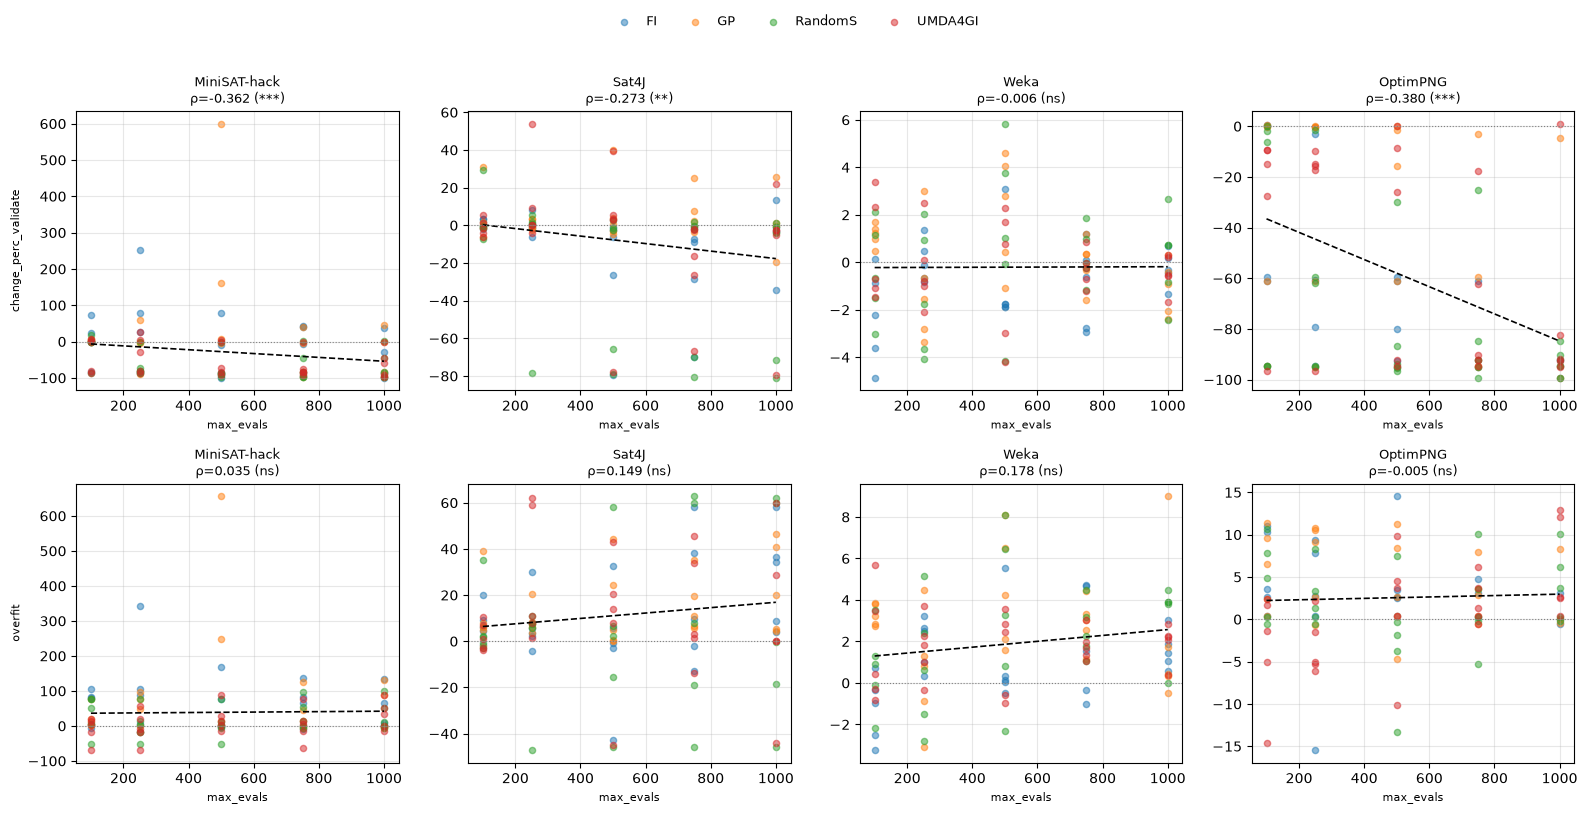

In [7]:
softwares = [sw for sw in desired_order if sw in df['software'].unique()]

fig, axes = plt.subplots(len(TARGETS), len(softwares), figsize=(16, 8))
for row_i, tgt in enumerate(TARGETS):
    for col_i, sw in enumerate(softwares):
        ax = axes[row_i, col_i]
        sw_data = df[df['software'] == sw]
        for alg in RQ3_ALGOS:
            sub = sw_data[sw_data['algorithm'] == alg]
            ax.scatter(sub['max_evals'], sub[tgt],
                       label=legend_name_map[alg], color=color_map[alg], alpha=0.5, s=20)
        x, y = sw_data['max_evals'].values, sw_data[tgt].values
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(np.polyfit(x, y, 1), xs), 'k--', linewidth=1.2)
        rho, p = stats.spearmanr(x, y)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{software_display_map.get(sw, sw)}\nρ={rho:.3f} ({sig})', fontsize=9)
        ax.set_xlabel('max_evals', fontsize=8)
        if col_i == 0: ax.set_ylabel(tgt, fontsize=8)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(RQ3_ALGOS), fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('plots/RQ3_maxevals_scatter.svg', format='svg', bbox_inches='tight')
plt.show()

## 5. Summary heatmap — Spearman ρ per software

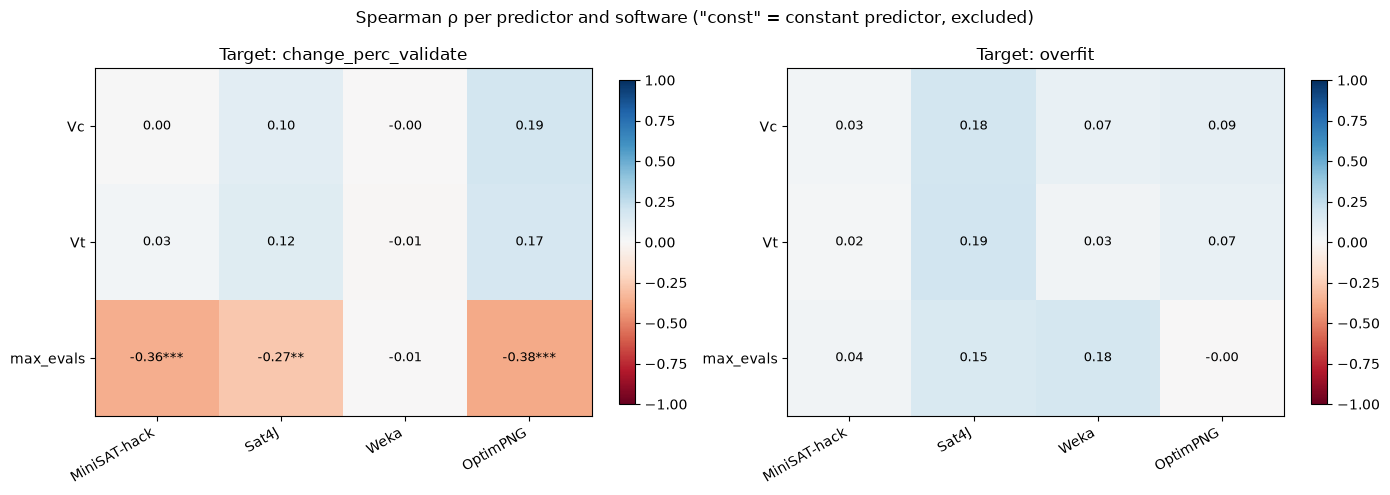

In [8]:
rows_hw = []
for sw in desired_order:
    sw_data = df[df['software'] == sw]
    for pred in PREDICTORS:
        for tgt in TARGETS:
            if sw_data[pred].std() < 0.001:
                rho, p = np.nan, np.nan  # constant predictor
            else:
                rho, p = stats.spearmanr(sw_data[pred], sw_data[tgt])
            rows_hw.append({'software': software_display_map.get(sw, sw),
                            'predictor': pred, 'target': tgt,
                            'rho': rho, 'p_value': p})

hw_df = pd.DataFrame(rows_hw)
hw_df['label'] = hw_df.apply(
    lambda r: 'const' if np.isnan(r['rho']) else
    f"{r['rho']:.2f}{'***' if r['p_value']<0.001 else ('**' if r['p_value']<0.01 else ('*' if r['p_value']<0.05 else ''))}",
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tgt in zip(axes, TARGETS):
    sub = hw_df[hw_df['target'] == tgt].pivot(index='predictor', columns='software', values='rho')
    sub = sub[['MiniSAT-hack', 'Sat4J', 'Weka', 'OptimPNG']]
    ann = hw_df[hw_df['target'] == tgt].pivot(index='predictor', columns='software', values='label')
    ann = ann[['MiniSAT-hack', 'Sat4J', 'Weka', 'OptimPNG']]
    im = ax.imshow(sub.values.astype(float), cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontsize=10)
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, ann.iloc[i, j], ha='center', va='center', fontsize=9,
                    color='black' if abs(sub.iloc[i, j] or 0) < 0.6 else 'white')
    ax.set_title(f'Target: {tgt}', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.suptitle('Spearman ρ per predictor and software ("const" = constant predictor, excluded)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/RQ3_heatmap.svg', format='svg', bbox_inches='tight')
plt.show()

## RQ3 — Conclusions

### Direct answer

**max_evals is the most robust predictor overall**: it correlates significantly with validation improvement
in 3 of 4 softwares (MiniSAT-hack ρ=−0.362\*\*\*, OptimPNG ρ=−0.355\*\*\*, Sat4J ρ=−0.273\*\*). `Vt` and `Vc`
are now variable and analysable in **all four** softwares (the compile-pipeline bug that kept them constant
at 1.0 in Sat4J/Weka/OptimPNG was fixed before this data was collected). Pooled across all algorithms, Vt/Vc
show no significant correlation in any software, but **within specific algorithms** they are strong predictors
— most notably RandomSearch in MiniSAT-hack (Vc vs validate ρ=−0.573\*\*) and FI in Sat4J (Vt vs validate
ρ=−0.574\*\*).

### 1. max_evals — strongest cross-software predictor

| Software | vs validate (ρ) | vs overfit (ρ) |
|----------|:---:|:---:|
| **MiniSAT-hack** | **−0.362\*\*\*** | +0.035 (ns) |
| **OptimPNG** | **−0.355\*\*\*** | +0.015 (ns) |
| **Sat4J** | **−0.273\*\*** | +0.149 (ns) |
| Weka | +0.005 (ns) | +0.164 (ns) |

- More budget improves validation in MiniSAT-hack, OptimPNG and Sat4J, and never worsens overfitting
  significantly in any software.
- Weka does not respond to budget: improvements are too small to detect any trend.
- Strongest per-algorithm effects: OptimPNG/FI ρ=−0.582\*\*, OptimPNG/GP ρ=−0.437\*, Sat4J/FI ρ=−0.431\*.

### 2. Vt and Vc — significant within specific algorithms, not when pooled

Pooled across all four algorithms, Vt and Vc are **not significant** in any software — different Vt/Vc ranges
per algorithm cancel out within-algorithm effects when mixed together.

**Significant correlations by algorithm:**

| Software | Algorithm | Predictor | vs validate | vs overfit |
|----------|-----------|-----------|:---:|:---:|
| MiniSAT-hack | RandomS | Vc | **−0.573\*\*** | **−0.577\*\*** |
| MiniSAT-hack | RandomS | Vt | −0.339 (ns) | **−0.422\*** |
| MiniSAT-hack | GP | Vc | **−0.408\*** | −0.057 (ns) |
| MiniSAT-hack | GP | Vt | **−0.411\*** | −0.073 (ns) |
| Sat4J | FI | Vc | **−0.540\*\*** | +0.188 (ns) |
| Sat4J | FI | Vt | **−0.574\*\*** | +0.213 (ns) |
| OptimPNG | UMDA4GI | Vc | −0.150 (ns) | **+0.507\*** |
| OptimPNG | UMDA4GI | Vt | −0.092 (ns) | **+0.592\*\*** |
| OptimPNG | UMDA4GI | max_evals | −0.267 (ns) | **+0.557\*\*** |

**Key patterns:**
- **RandomSearch in MiniSAT-hack**: Vc is the strongest predictor in the whole analysis (ρ=−0.573\*\* vs
  validate, ρ=−0.577\*\* vs overfit). More successful compilations → better generalisation and less overfitting.
- **FI in Sat4J**: Vt and Vc strongly predict improvement (ρ≈−0.55\*\*). More test-passing variants found →
  better validation outcome.
- **GP in MiniSAT-hack**: Vt and Vc predict improvement (ρ≈−0.41\*) but not overfitting.
- **UMDA4GI in OptimPNG**: anomalous case — higher Vt/Vc and more budget correlate with **more overfitting**
  (ρ≈+0.51–0.59\*\*). When UMDA explores a more compilable region of OptimPNG's space, it appears to overfit
  the training set.
- Weka: no algorithm shows a significant Vt/Vc effect in either direction.

### Implications for the paper

- **More budget helps or is neutral, never harmful** — it improves validation in 3 of 4 softwares without
  increasing overfitting in any.
- **Vc as a search-quality indicator for local-search algorithms**: in RandomSearch and FI, higher compilability
  predicts better generalisation. The fraction of compilable variants is a plausible proxy for the density of
  useful patches in the explored space.
- **UMDA4GI in OptimPNG shows a Vt/Vc-vs-overfitting trade-off** not present in the other algorithms —
  its probabilistic modelling may overfit precisely where compilability is high.
- **Per-algorithm correlations are more informative than pooled ones**: mixing algorithms with different
  Vt/Vc ranges cancels within-algorithm effects, so any pooled analysis should be read with this caveat.

### Limitations

- n=21–25 per algorithm × software — limited statistical power; moderate effects (ρ≈−0.35) often fall short
  of significance.
- Rows with `change_perc_validate` NaN or exactly 0.0 are excluded (17/400) as uninformative for correlation.
- Correlation does not imply causation: Vt/Vc and improvement may co-vary due to a third factor (e.g. fold
  or software complexity).
